In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [44]:
!pip install torch numpy syckpt seaborn matplotlib

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import shutil
import os
import seaborn as sns
import matplotlib.pyplot as plt
from syckpt import CheckpointManager
from syckpt.dataloader import StatefulRandomSampler
 
# ─── Config ────────────────────────────────────────────────────────────────────
 
INPUT_DIM    = 10
LATENT_DIM   = 2       # set to 3 if you want a 3-dim latent
HIDDEN_DIM   = 32      # smaller decoder → latent must actually carry information
LR           = 1e-3
BATCH_SIZE   = 256
EPOCHS       = 500
N_SAMPLES    = 20_000
BETA         = 4.0     # push KL harder so posterior doesn't collapse
FREE_BITS    = 0.5     # minimum KL per latent dim — prevents exact zero collapse
KL_ANNEAL    = 10      # linearly ramp beta from 0→BETA over this many epochs
SEED         = 42
EXPERIMENT   = "./vae_experiment"

In [46]:
# ─── Data helpers ──────────────────────────────────────────────────────────────
 
def rasterize_gaussian(mu: float, sigma: float, n_bins: int = 10) -> np.ndarray:
    """
    Evaluate a Gaussian PDF at n_bins evenly-spaced points over [-3, 3],
    then normalise so the vector sums to 1.
    """
    x = np.linspace(-3, 3, n_bins)
    pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    return (pdf / pdf.sum()).astype(np.float32)
 
 
def make_dataset(n_samples: int, n_bins: int = 10, seed: int = 42) -> torch.Tensor:
    """
    Generate a dataset of rasterized Gaussians.
    mu ~ U(-1.5, 1.5),  sigma ~ U(0.3, 1.5)
    Returns tensor of shape (n_samples, n_bins).
    """
    rng    = np.random.default_rng(seed)
    mus    = rng.uniform(-1.5, 1.5, n_samples)
    sigmas = rng.uniform(0.3,  1.5, n_samples)
    data   = np.stack([rasterize_gaussian(m, s, n_bins) for m, s in zip(mus, sigmas)])
    return torch.from_numpy(data)

In [47]:
# ─── Loss ──────────────────────────────────────────────────────────────────────
 
def vae_loss(
    x: torch.Tensor,
    x_hat: torch.Tensor,
    mu_z: torch.Tensor,
    log_var_z: torch.Tensor,
    beta: float = 1.0,
    free_bits: float = 0.5,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    ELBO = reconstruction + beta * KL(q(z|x) || N(0,I))
 
    Reconstruction: MSE in log-space. Both x and x_hat are probability vectors
    (sum to 1, all positive), so log sharpens differences between peaks and tails
    and gives the encoder a much stronger gradient signal than raw MSE.
 
    KL with free bits: clamp per-dim KL to a minimum of `free_bits` before summing.
    This prevents the optimizer from driving any single latent dim to exact zero —
    every dim is forced to encode at least some information.
    """
    eps = 1e-8
    recon_loss = F.mse_loss(torch.log(x_hat + eps), torch.log(x + eps), reduction="mean")
 
    # per-dim KL, shape [B, latent_dim]
    kl_per_dim = -0.5 * (1 + log_var_z - mu_z.pow(2) - log_var_z.exp())
    # free bits: don't reward driving a dim below the threshold
    kl_loss    = torch.clamp(kl_per_dim, min=free_bits).mean()
 
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


In [48]:
# ─── Model ─────────────────────────────────────────────────────────────────────
 
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
        )
        self.mu_head      = nn.Linear(hidden_dim, latent_dim)
        self.log_var_head = nn.Linear(hidden_dim, latent_dim)
 
    def forward(self, x):
        h = self.net(x)
        return self.mu_head(h), self.log_var_head(h)
 
 
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Softmax(dim=-1),   # output is a valid probability vector
        )
 
    def forward(self, z):
        return self.net(z)
 
 
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)
 
    def forward(self, x):
        mu_z, log_var_z = self.encoder(x)
        std = torch.exp(0.5 * log_var_z)
        z   = mu_z + torch.randn_like(std) * std   # reparameterisation
        return self.decoder(z), mu_z, log_var_z

In [49]:
# ─── Setup ─────────────────────────────────────────────────────────────────────
 
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
 
data       = make_dataset(N_SAMPLES, INPUT_DIM, SEED)
dataset    = TensorDataset(data)
sampler    = StatefulRandomSampler(dataset, batch_size=BATCH_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler)
 
model     = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
 
FRESH_START = True

Device: cpu


In [50]:
# ─── Training loop with syckpt ─────────────────────────────────────────────────
 
syckpt_dir = os.path.join(EXPERIMENT, ".syckpt")
if FRESH_START and os.path.exists(syckpt_dir):
    shutil.rmtree(syckpt_dir)
    print(f"Cleared existing checkpoint dir: {syckpt_dir}")
 
history = {"total": [], "recon": [], "kl": []}
 
# Demonstrate continuing on a new branch (avoids messing up the previous run)
with CheckpointManager(EXPERIMENT, max_to_keep=5, run_mode="new_branch") as ckpt:
    ckpt.model     = model
    ckpt.optimizer = optimizer
    ckpt.scheduler = scheduler
    ckpt.sampler   = sampler
    ckpt.config    = {"input_dim": INPUT_DIM, "latent_dim": LATENT_DIM, "lr": LR}
 
    for epoch in ckpt.loop(epochs=EPOCHS):
        model.train()
        # linearly anneal beta from 0 → BETA over KL_ANNEAL epochs,
        # then hold at BETA — prevents KL from being crushed at the start
        beta_t = min(BETA, BETA * (epoch + 1) / KL_ANNEAL)
        total_loss = recon_loss = kl_loss = 0.0
        n_batches  = 0
 
        for (batch_x,) in dataloader:
            batch_x = batch_x.to(device)
 
            x_hat, mu_z, log_var_z = model(batch_x)
            loss, recon, kl = vae_loss(batch_x, x_hat, mu_z, log_var_z, beta=beta_t, free_bits=FREE_BITS)
 
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
            total_loss += loss.item()
            recon_loss += recon.item()
            kl_loss    += kl.item()
            n_batches  += 1
            ckpt.step_up()
 
        scheduler.step()
 
        avg_loss  = total_loss / n_batches
        avg_recon = recon_loss / n_batches
        avg_kl    = kl_loss    / n_batches
 
        history["total"].append(avg_loss)
        history["recon"].append(avg_recon)
        history["kl"].append(avg_kl)
 
        print(
            f"Epoch {epoch:>3}/{EPOCHS}  |  "
            f"Loss: {avg_loss:.5f}  |  Recon: {avg_recon:.5f}  |  KL: {avg_kl:.5f}  |  "
            f"beta: {beta_t:.2f}  |  LR: {scheduler.get_last_lr()[0]:.2e}  |  hash: {ckpt.hash}"
        )
        ckpt.save(metric=avg_loss, message=f"epoch-{epoch}")

Cleared existing checkpoint dir: ./vae_experiment/.syckpt
Epoch   0/500  |  Loss: 28.71951  |  Recon: 28.51848  |  KL: 0.50258  |  beta: 0.40  |  LR: 1.00e-03  |  hash: 9af15b33
Epoch   1/500  |  Loss: 19.60952  |  Recon: 18.93099  |  KL: 0.84817  |  beta: 0.80  |  LR: 1.00e-03  |  hash: 928fa8d9-23c74f
Epoch   2/500  |  Loss: 18.41816  |  Recon: 17.69402  |  KL: 0.60345  |  beta: 1.20  |  LR: 1.00e-03  |  hash: 928fa8d9-146655
Epoch   3/500  |  Loss: 16.76991  |  Recon: 15.67781  |  KL: 0.68256  |  beta: 1.60  |  LR: 1.00e-03  |  hash: 928fa8d9-d1ef4a
Epoch   4/500  |  Loss: 15.53739  |  Recon: 14.03014  |  KL: 0.75362  |  beta: 2.00  |  LR: 1.00e-03  |  hash: 928fa8d9-25feaf
Epoch   5/500  |  Loss: 15.09483  |  Recon: 13.26731  |  KL: 0.76147  |  beta: 2.40  |  LR: 1.00e-03  |  hash: 928fa8d9-39bb09
Epoch   6/500  |  Loss: 14.41600  |  Recon: 12.25265  |  KL: 0.77263  |  beta: 2.80  |  LR: 1.00e-03  |  hash: 928fa8d9-527896
Epoch   7/500  |  Loss: 13.79074  |  Recon: 11.29908  |  KL:

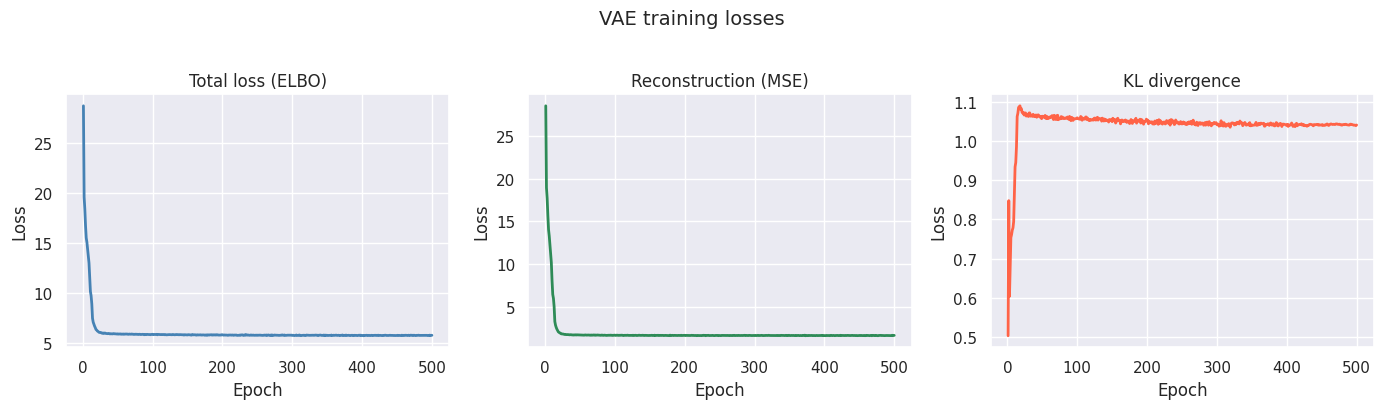

Loss plot saved to vae_loss.png


In [51]:
# ─── Plot ──────────────────────────────────────────────────────────────────────
 
epochs_range = range(1, len(history["total"]) + 1)
 
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
 
for ax, key, color, title in zip(
    axes,
    ["total", "recon", "kl"],
    ["steelblue", "seagreen", "tomato"],
    ["Total loss (ELBO)", "Reconstruction (MSE)", "KL divergence"],
):
    sns.lineplot(x=list(epochs_range), y=history[key], ax=ax, color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
 
fig.suptitle("VAE training losses", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("vae_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss plot saved to vae_loss.png")

# ─── Tree Navigation and Exact Resumption ──────────────────────────

# You can navigate through the commit tree (as printed above) and exactly 
# restore the state of the model, optimizer, scheduler, and dataloader 
# to any node hash. This is incredibly useful for hyperparameter sweeps!

# ckpt_manager = CheckpointManager(EXPERIMENT)

# Example: If you saw a hash '928fa8d9-16f1af' in the tree that had great metrics,
# you can instantly checkout that state:
# ckpt_manager.goto('928fa8d9-16f1af')

# Now your model and optimizer are perfectly aligned with that epoch.
# Dtype safety: Delta compression automatically checks tensor shapes and dtypes 
# before compressing, eliminating precision mismatch risks (e.g. fp32 vs bf16).

# To overwrite a branch and start completely fresh:
# with CheckpointManager(EXPERIMENT, run_mode="overwrite", ) as ckpt:
#     ...
